In [3]:
!pip install numpy matplotlib scikit-fuzzy
!pip install scypy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.2 MB/s eta 0:00:00


Nota do serviço (0-10) [7]: 7
Nota da comida (0-10) [3]: 5

=> Gorjeta sugerida: 15.7%


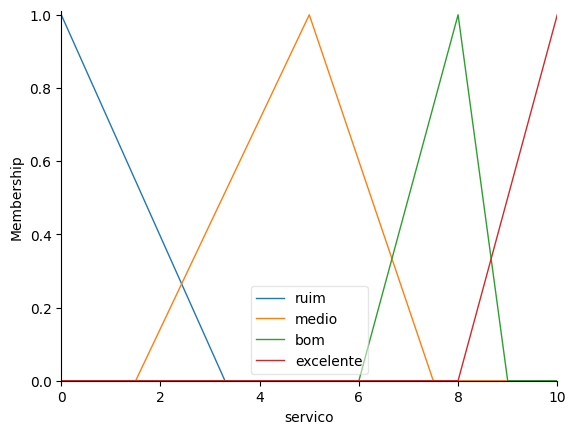

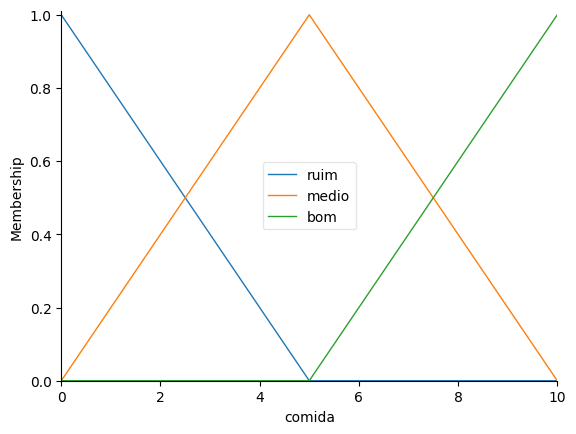

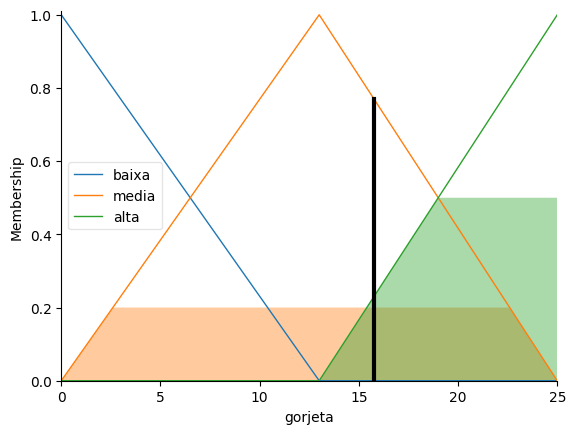

In [4]:
"""
AULA DE LÓGICA FUZZY - Código 2 (Laboratório Modificado)
Versão com Funções Triangulares (trimf), 4 Conjuntos no Serviço e Operadores Combinados.
"""

import matplotlib.pyplot as plt
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ---------- 1) Variáveis linguísticas (universos de discurso) ----------
servico = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "servico")  # nota 0-10
comida = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "comida")  # nota 0-10

gorjeta = ctrl.Consequent(
    np.arange(0, 25.01, 0.5), "gorjeta", defuzzify_method="centroid"
)

# ---------- 2) Conjuntos fuzzy (funções de pertinência Triangulares) ----------
# Serviço (4 conjuntos triangulares: ruim, medio, bom, excelente)
servico["ruim"] = fuzz.trimf(servico.universe, [0, 0, 3.3])
servico["medio"] = fuzz.trimf(servico.universe, [1.5, 5, 7.5])
servico["bom"] = fuzz.trimf(servico.universe, [6, 8, 9])
servico["excelente"] = fuzz.trimf(servico.universe, [8, 10, 10])

# Comida (3 conjuntos triangulares)
comida["ruim"] = fuzz.trimf(comida.universe, [0, 0, 5])
comida["medio"] = fuzz.trimf(comida.universe, [0, 5, 10])
comida["bom"] = fuzz.trimf(comida.universe, [5, 10, 10])

# Gorjeta (3 conjuntos triangulares)
gorjeta["baixa"] = fuzz.trimf(gorjeta.universe, [0, 0, 13])
gorjeta["media"] = fuzz.trimf(gorjeta.universe, [0, 13, 25])
gorjeta["alta"] = fuzz.trimf(gorjeta.universe, [13, 25, 25])

# ---------- 3) Base de regras (| = OU, & = E, ~ = NÃO) ----------
regras = [
    # Experimento 1: Regra com & em vez de isolado
    ctrl.Rule(servico["medio"] & comida["medio"], gorjeta["media"]),
    # Regras de extremos
    ctrl.Rule(servico["ruim"] | comida["ruim"], gorjeta["baixa"]),
    ctrl.Rule(servico["bom"] | comida["bom"], gorjeta["alta"]),
    # Experimento 4: Regra para o 4º conjunto do serviço
    ctrl.Rule(servico["excelente"], gorjeta["alta"]),
]

# ---------- 4) Simulação ----------
sistema = ctrl.ControlSystem(regras)
sim = ctrl.ControlSystemSimulation(sistema)


def pedir_nota(texto, padrao):
  """Lê uma nota de 0 a 10; se o aluno só apertar Enter, usa o padrão."""
  resposta = input(f"{texto} (0-10) [{padrao}]: ").strip()
  return float(resposta.replace(",", ".")) if resposta else padrao


# Leitura dos dados do usuário
nota_servico = pedir_nota("Nota do serviço", 7)
nota_comida = pedir_nota("Nota da comida", 3)

sim.input["servico"] = nota_servico
sim.input["comida"] = nota_comida
sim.compute()

print(f"\n=> Gorjeta sugerida: {sim.output['gorjeta']:.1f}%")

# ---------- 5) Gráficos ----------
servico.view()  # Exibe os 4 triângulos do serviço
comida.view()  # Exibe os triângulos da comida
gorjeta.view(sim=sim)  # Área agregada recortada + linha do centroide
plt.show()